Training an FNN neural network with scaled dataframe

In [1]:
!pip install keras
!pip install tensorflow
!pip install scikeras

Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None
Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None
Defaulting to user installation because normal site-packages is not writeable
distutils: /users/imbahndu/.local/lib/python3.9/site-packages
sysconfig: /users/imbahndu/.local/lib64/python3.9/site-packages
user = True
home = None
root = None
prefix = None


In [2]:
#Importing modules and librarie
import tensorflow.keras as keras
import pandas as pd
import numpy as np
from scikeras.wrappers import KerasClassifier

2025-07-24 11:36:45.977294: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-24 11:36:46.025776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753371406.109932  473029 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753371406.126507  473029 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753371406.181531  473029 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
#Loading dataframe 
df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/Typing dataset/nn.csv")


In [4]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons
0,-0.917502,1.779560,-1.200823,0.282236,-0.074398,False
1,-0.917502,-1.005882,0.539641,-0.343869,-0.289345,True
2,1.089916,1.872249,1.409874,-0.452636,-1.396361,True
3,1.089916,-0.449744,-0.330591,-0.507019,-0.750733,False
4,1.089916,-0.354678,-0.330591,1.126572,1.248354,True
...,...,...,...,...,...,...
56638,-0.917502,1.594181,-1.200823,-1.868694,-0.750733,True
56639,-0.917502,-0.727813,-1.200823,-0.452636,-0.412172,True
56640,-0.917502,-1.469330,-1.200823,1.507953,1.924689,True
56641,1.089916,-0.542434,-0.330591,-0.561402,-1.273535,False


In [5]:
#Dropping the hand and direction columns since they might not be predictive
df = df.drop(columns = ["Hand", "Direction"])

In [6]:
df["Parkinsons"].isna().sum()

0

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
df["Parkinsons"].isna().sum()

0

In [9]:
df["Parkinsons"].value_counts()

Parkinsons
False    29173
True     27470
Name: count, dtype: int64

In [10]:
#Dividing into train_test_split and defining labels
df["Parkinsons"] = df["Parkinsons"].astype(int)

print(df["Parkinsons"].value_counts())

y = df["Parkinsons"]

X = df.drop(columns=["Parkinsons"])

X_train, X_test, y_train , y_test = train_test_split(X, y, random_state=42, test_size=0.2)


Parkinsons
0    29173
1    27470
Name: count, dtype: int64


In [11]:
#Making sure my featurs are int or floats
print(X_train.dtypes)

HoldTime       float64
LatencyTime    float64
FlightTime     float64
dtype: object


In [12]:
print(y)

0        0
1        1
2        1
3        0
4        1
        ..
56638    1
56639    1
56640    1
56641    0
56642    0
Name: Parkinsons, Length: 56643, dtype: int64


In [13]:
#Defining the loss function  and optimizer
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

optim = keras.optimizers.Adam(learning_rate=0.001)


2025-07-24 11:36:59.468820: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [14]:
#Creating the NN Architecture 


nn_model = keras.Sequential()

#Input layer 
input_layer = keras.layers.InputLayer(input_shape = (len(X_train.columns),))
nn_model.add(input_layer)

#Hidden layer 1
hidden_layer_1 = keras.layers.Dense(units = 128, activation="relu")
nn_model.add(hidden_layer_1)

#Hidden layer 2
hidden_layer_2 = keras.layers.Dense(units=64, activation="relu")
nn_model.add(hidden_layer_2)

#hidden layer 3
hidden_layer_3 = keras.layers.Dense(units=32, activation="relu")
nn_model.add(hidden_layer_3)
dropout = keras.layers.Dropout(0.2)
nn_model.add(dropout)

#extra hidden layer 
hidden_layer_5 = keras.layers.Dense(units=16, activation="relu")
nn_model.add(hidden_layer_5)
nn_model.add(keras.layers.Dropout(0.2))

#hidden layer 4 / output 5
hidden_layer_4 = keras.layers.Dense(units=1, activation="sigmoid")
nn_model.add(hidden_layer_4)


 #Compiling the model
nn_model.compile(optimizer=optim, loss=loss_fn, metrics=["accuracy"])



/users/imbahndu/.local/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [15]:
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,393 (44.50 KB)

 Trainable params: 11,393 (44.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#Fitting the model
num_epochs = 50
model = nn_model.fit(X_train, y_train, epochs=num_epochs, validation_split=0.3)

Epoch 1/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5148 - loss: 0.6916 - val_accuracy: 0.5395 - val_loss: 0.6877
Epoch 2/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5329 - loss: 0.6896 - val_accuracy: 0.5444 - val_loss: 0.6869
Epoch 3/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5384 - loss: 0.6875 - val_accuracy: 0.5466 - val_loss: 0.6861
Epoch 4/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5434 - loss: 0.6873 - val_accuracy: 0.5455 - val_loss: 0.6858
Epoch 5/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5396 - loss: 0.6859 - val_accuracy: 0.5517 - val_loss: 0.6850
Epoch 6/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5411 - loss: 0.6877 - val_accuracy: 0.5503 - val_loss: 0.6849
Epoch 7/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5478 - loss: 0.6848 - val_accuracy: 0.5573 - val_loss: 0.6847
Epoch 8/50
992/992 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5470 - loss: 0.6844 - val_accuracy

In [17]:
#Evaluating the model's accuracy and loss over time through visualizations
print(model.history.keys())
import matplotlib.pyplot as plt

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


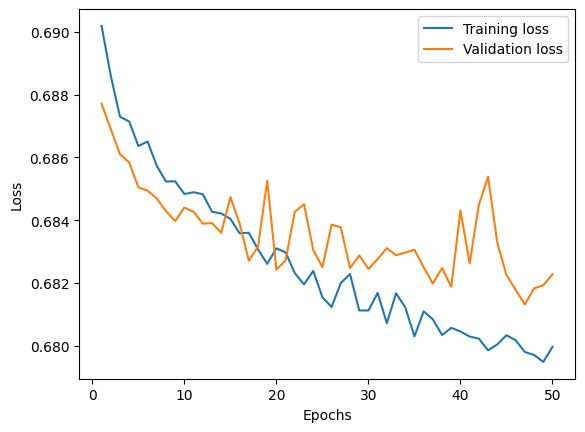

In [18]:
#Plotting loss 
plt.plot(range(1, num_epochs+1), model.history['loss'], label="Training loss")
plt.plot(range(1, num_epochs+1), model.history['val_loss'], label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

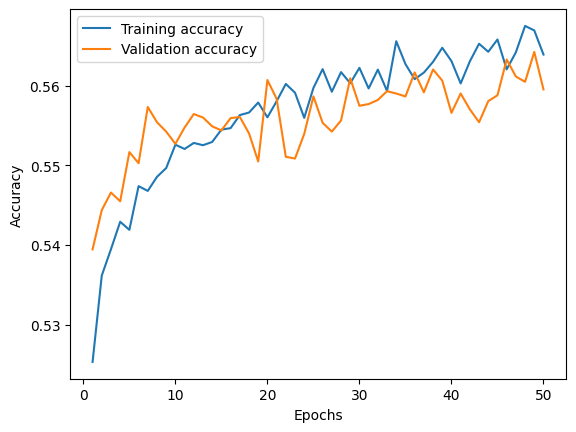

In [19]:
plt.plot(range(1, num_epochs+1), model.history['accuracy'], label="Training accuracy")
plt.plot(range(1, num_epochs+1), model.history['val_accuracy'], label="Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [20]:
loss, accuracy = nn_model.evaluate(X_test,y_test)
print("Loss is ", loss)
print("Accuracy is", accuracy)

355/355 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5547 - loss: 0.6811
Loss is  0.6820586323738098
Accuracy is 0.5547709465026855


In [21]:
#Predictions on X_test and setting threshold to 
predict_label = nn_model.predict(X_test)
predict_label_int = (predict_label >= 0.5).astype(int)

355/355 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [22]:
#Confusion matrix and classification report 

print(confusion_matrix(y_test, predict_label_int))

print(classification_report(y_test, predict_label_int))

print(accuracy_score(y_test, predict_label_int))

[[4196 1655]
 [3389 2089]]
              precision    recall  f1-score   support

           0       0.55      0.72      0.62      5851
           1       0.56      0.38      0.45      5478

    accuracy                           0.55     11329
   macro avg       0.56      0.55      0.54     11329
weighted avg       0.56      0.55      0.54     11329

0.5547709418307


/tmp/ipykernel_473029/78027907.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<function matplotlib.pyplot.show(close=None, block=None)>

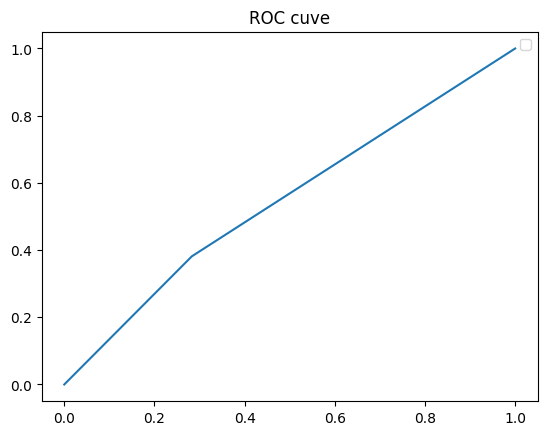

In [23]:
from sklearn.metrics import roc_curve
import seaborn as sns

fpr, tpr, threshold = roc_curve(y_test, predict_label_int)
sns.lineplot(x=fpr, y=tpr)
plt.title("ROC cuve")
plt.legend()
plt.show